In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import arviz as az
import colorsys

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "2" # second gpu
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140

from matplotlib import rc

rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
rc('text', usetex=False)

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
def train_hmm(model, emissions, inputs, verbose = True):
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions, inputs = inputs, num_iters = 10,verbose = verbose)
    return model, fit_params, lps

def scale_to_bounds(x, axis=0, eps=1e-3):
    """
    Linearly rescales x along `axis` so that
      min → eps, max → 1-eps,
    and everything else is in between.
    """
    # compute min and max (keepdims so we can broadcast)
    mn = x.min(axis=axis, keepdims=True)
    mx = x.max(axis=axis, keepdims=True)
    # normalize to [0,1]
    x0 = (x - mn) / (mx - mn)
    # stretch to [eps, 1-eps]
    return x0 * (1 - 2*eps) + eps
  
def impute_with_median(data):
    median_rt = np.nanmedian(data)
    rt_imputed = data.copy()
    rt_imputed[rt_imputed == 0] = median_rt
    return rt_imputed

def impute_with_lin_interpolation(data):
    oshape = data.shape
    rt_imputed = data.flatten().copy()
    idx = np.arange(rt_imputed.size)
    good = rt_imputed != 0
    
    # interpolate where values are zero
    rt_imputed[rt_imputed == 0] = np.interp(
        idx[~good], 
        idx[good], 
        rt_imputed[good], 
    )
    return rt_imputed.reshape(oshape)

In [4]:
# Modeling setup:
# emissions : 3 components -> reaction time, response angle, response error

# inputs for them:
# reaction time: error, surprise | attention, coherence, expectiation | bias
# response angle: stim, prev. stim, pre. resp | attention, coherence, expectation | bias
# response error: | attention, coherence, expectation | bias

# models for them:
# reaction time: Gamma GLM
# response angle: von Mises GLM
# response error: Beta GLM

In [5]:
rdf = r_table.copy()

# 1) Compute previous-trial target & response
rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])

# 2) Reshape metadata into (n_trials, T, 1)
n_trials = rdf.shape[0] // 120
T = 120
reshape = lambda x: x.values.reshape(n_trials, T, 1).astype(np.float32)

baseline_bias    = np.ones((n_trials, T, 1), dtype=np.float32)
attention        = (rdf['att'] == "focused").astype(np.float32)
coherence        = (rdf['coh'] == "high").astype(np.float32)
expectation      = (rdf['exp_al'] == "expected").astype(np.float32)

attention   = reshape(attention)
coherence   = reshape(coherence)
expectation = reshape(expectation)

# 3) Error predictor for RT: signed error in radians
# resp_err = np.deg2rad(rdf['resp_err'])
# resp_err = reshape(resp_err)

# 4) Stimuli and history for RA
stim       = np.deg2rad(rdf['t_calib'])
prev_stim  = np.deg2rad(rdf['prev_target'])
prev_resp  = np.deg2rad(rdf['prev_resp'])

# wrap to [-pi, pi]
wrap = lambda x: ((x + np.pi) % (2*np.pi)) - np.pi
stim      = wrap(reshape(stim))
prev_stim = wrap(reshape(prev_stim))
prev_resp = wrap(reshape(prev_resp))

# 5) Reaction time (ms)
rt_raw = (rdf['f_resp'].values - 250).reshape(n_trials, T, 1) * (1000/120)
# reaction_time = np.clip(rt_raw, 0.01, None).astype(np.float32)
reaction_time = impute_with_lin_interpolation(rt_raw)

# 6) Response angle in radians, wrapped
response_angle = np.deg2rad(rdf['resp']).values
response_angle = wrap(response_angle.reshape(n_trials, T, 1))

# 7) Response error for emissions (positive)
err_raw = rdf['resp_err'].values.reshape(n_trials, T, 1)
err_neg_mask = rdf['v_err'].values.reshape(n_trials, T, 1) < 0
err_raw[err_neg_mask] = err_raw[err_neg_mask] * -1
response_error = err_raw
abs_response_error = np.abs(response_error)

# 8) Build feature blocks
# RT features: [1, Error, Att, Coh, Exp, Error*Att, Error*Coh, Error*Exp]
x_rt = np.concatenate([
    baseline_bias,
    abs_response_error,
    attention, coherence, expectation,
    abs_response_error * attention,
    abs_response_error * coherence,
    abs_response_error * expectation
], axis=-1)

# RA features: [1, stim, prev_stim, prev_resp, Att, Coh, Exp]
x_ra = np.concatenate([
    baseline_bias,
    stim, prev_stim, prev_resp,
    attention, coherence, expectation
], axis=-1)

# RE features: [1, RT, Att, Coh, Exp, RT*Att, RT*Coh, RT*Exp]
# RE features: [1, Att, Coh, Exp]
x_re = np.concatenate([
    baseline_bias,
    # reaction_time,
    attention, coherence, expectation,
    # reaction_time * attention,
    # reaction_time * coherence,
    # reaction_time * expectation
], axis=-1)

x_rt = jnp.array(x_rt)
x_ra = jnp.array(x_ra)
x_re = jnp.array(x_re)

y_rt = jnp.array(reaction_time)
y_ra = jnp.array(response_angle)
y_re = jnp.array(response_error)

# Verify shapes
print("inputs shape:", (x_rt.shape,x_ra.shape,x_re.shape) )
print("emissions shape:", (y_rt.shape,y_ra.shape,y_re.shape) )


inputs shape: ((288, 120, 8), (288, 120, 7), (288, 120, 4))
emissions shape: ((288, 120, 1), (288, 120, 1), (288, 120, 1))


In [6]:
# plt.hist(response_angle.flatten(), bins=1000, density=True)
# plt.show()
# plt.hist(reaction_time.flatten(), bins=1000, density=True)
# plt.show()
# plt.hist(response_error.flatten(), bins=1000, density=True)
# plt.show()

## Visualization Settings

In [7]:
to_train = ((x_rt, y_rt), (x_ra, y_ra), (x_re, y_re))
input_dims = (x_rt.shape[-1], x_ra.shape[-1], x_re.shape[-1])
emission_dims = (y_rt.shape[-1], y_ra.shape[-1], y_re.shape[-1])
bmodels = (BlockHMMrt, BlockHMMra, BlockHMMre)
onemodels = (BlockOneRT, BlockOneRA, BlockOneRE)
colors = ('#1f77b4', '#ff7f0e', '#2ca02c')
cmaps = [mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["white", color], N=256) for color in colors]
titles = ('Reaction Time', 'Response Angle', 'Response Error')
chosen_states = ( 2, 2, 2)
dirs = (
    './caches/rt',
    './caches/ra',
    './caches/re'
)

In [8]:
bar_kwargs = {
    'edgecolor': 'black',
    'linewidth': 1.5,
    'width': 0.3,
    'rot': 0,
}

In [9]:
# global parameters

with open(f'./caches/rt/global_params.pkl', 'rb') as f: rt_global_params = pickle.load(f)
with open(f'./caches/ra/global_params.pkl', 'rb') as f: ra_global_params = pickle.load(f)
with open(f'./caches/re/global_params.pkl', 'rb') as f: re_global_params = pickle.load(f)

# cross-validation
with open(f'./caches/rt/sub_crossval_results.pkl', 'rb') as f: rt_sub_crossval = pickle.load(f)
with open(f'./caches/ra/sub_crossval_results.pkl', 'rb') as f: ra_sub_crossval = pickle.load(f)
with open(f'./caches/re/sub_crossval_results.pkl', 'rb') as f: re_sub_crossval = pickle.load(f)
    
# One-state models
with open(f'./caches/rt/one_crossval_results.pkl', 'rb') as f: rt_one_state = pickle.load(f)
with open(f'./caches/ra/one_crossval_results.pkl', 'rb') as f: ra_one_state = pickle.load(f)
with open(f'./caches/re/one_crossval_results.pkl', 'rb') as f: re_one_state = pickle.load(f)

# subject-specific parameters
with open(f'./caches/rt/sub_params.pkl', 'rb') as f: rt_sub_params = pickle.load(f)
with open(f'./caches/ra/sub_params.pkl', 'rb') as f: ra_sub_params = pickle.load(f)
with open(f'./caches/re/sub_params.pkl', 'rb') as f: re_sub_params = pickle.load(f)

# ml states
with open(f'./caches/rt/ml_states.pkl', 'rb') as f: rt_ml_states = pickle.load(f)
with open(f'./caches/ra/ml_states.pkl', 'rb') as f: ra_ml_states = pickle.load(f)
with open(f'./caches/re/ml_states.pkl', 'rb') as f: re_ml_states = pickle.load(f)

# smoothed posteriors
with open(f'./caches/rt/smoothed_states.pkl', 'rb') as f: rt_smoothed_posteriors = pickle.load(f)
with open(f'./caches/ra/smoothed_states.pkl', 'rb') as f: ra_smoothed_posteriors = pickle.load(f)
with open(f'./caches/re/smoothed_states.pkl', 'rb') as f: re_smoothed_posteriors = pickle.load(f)

In [10]:
def move_ax_to_right(ax):
    # hide the left spine, show the right one
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)

    # move the y-axis ticks and label to the right
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')

    return ax

def plot_block(mean, sem=None, label="", color="k", line_style='-', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))
    
    ax.plot(
        np.arange(120),
        mean,
        line_style,
        color=color,
        label=label,
        linewidth=2,
        markersize=5
    )
    if sem is not None:
        ax.fill_between(
            np.arange(120),
            mean - sem,
            mean + sem,
            color=color,
            alpha=0.1
        )
    
    return ax

In [11]:
def get_aic_bic(full_crossval, input_dim, output_dim):

    all_cv = []
    all_ll = []

    for idx in range(12):
        sb = []
        ll = []
        for nstate in range(1,10):
            sb.append(full_crossval[idx][nstate].mean())
            ll.append(full_crossval[idx][nstate])
        all_cv.append(sb)
        ll[0] = ll[0].reshape(24, -1).sum(axis=1)
        all_ll.append(ll)

    all_cv = np.array(all_cv)
    all_ll = np.array(all_ll)

    all_aic, all_bic = [], []
    for idx, subjects in enumerate(all_ll):
        aic, bic = [], []
        for i, (n_state, ll) in enumerate(zip(np.arange(1,10), subjects)):
            a, b = calc_aic_bic_vhmm(n_state = n_state, log_likelihood = ll, input_dim = input_dim, output_dim = output_dim, T = 120)
            # print(f"Model with {n_state} states has AIC: {aic} and BIC: {bic}")
            aic.append(a)
            bic.append(b)
        all_aic.append(aic)
        all_bic.append(bic)
    all_aic, all_bic = np.array(all_aic).mean(axis=-1), np.array(all_bic).mean(axis=-1)
    
    return all_cv, all_aic, all_bic


In [12]:
def plot_mloocv(all_cv, all_aic, all_bic, title):
    fig, ax1 = plt.subplots(figsize=(7, 4))

    # Plot each individual log-likelihood curve on ax1 (left axis)
    for subjects in all_cv:
        ax1.plot(np.arange(1, 10), subjects, "-k", alpha=0.1, linewidth=1)

    # Plot the mean log-likelihood on ax1 in green
    ax1.plot(np.arange(1, 10), np.array(all_cv).mean(axis=0), "-o", color="#216976",
            alpha=1, label="Loglik", linewidth=4, markersize=8)
    ax1.set_xlabel("Number of States")
    ax1.set_ylabel("Marginal-log-likelihood", color="#216976")
    ax1.tick_params(axis='y', labelcolor="#216976")
    ax1.set_xticks(np.arange(1, 10))
    ax1.set_title(f"{title} Leave-one-out cross-validation")

    # Create a second y-axis sharing the same x-axis for AIC/BIC
    ax2 = ax1.twinx()
    ax2.plot(np.arange(1, 10), np.array(all_aic).mean(axis=(0)), "-k", 
            alpha=0.5, label="AIC", linewidth=3, markersize=5)
    ax2.plot(np.arange(1, 10), np.array(all_bic).mean(axis=(0)), "--k", 
            alpha=0.5, label="BIC", linewidth=3, markersize=5)
    ax2.set_ylabel("AIC/BIC", color="k")
    ax2.tick_params(axis='y', labelcolor="k")

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=False)

    # Axis border off
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(True)
    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    plt.show()
    # plt.savefig("mloocv.svg", format="svg", transparent=True)

## Crossvalidations

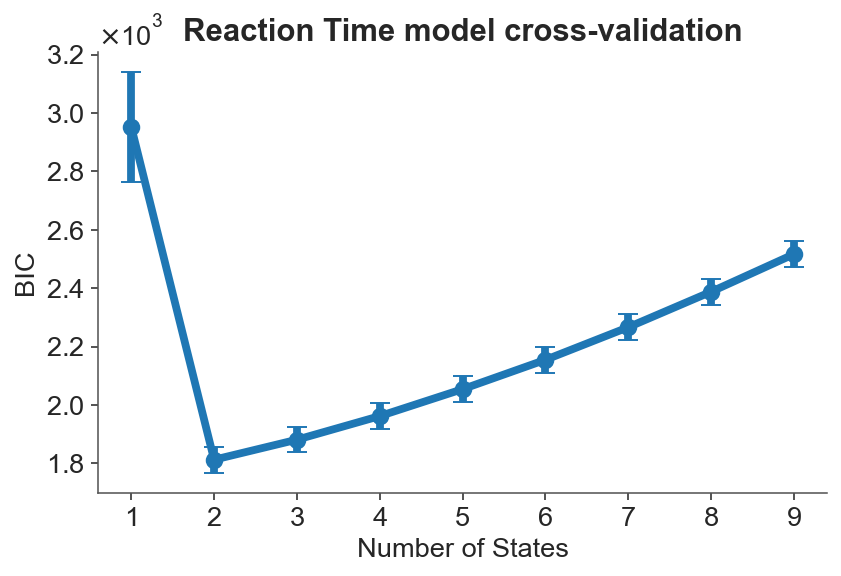

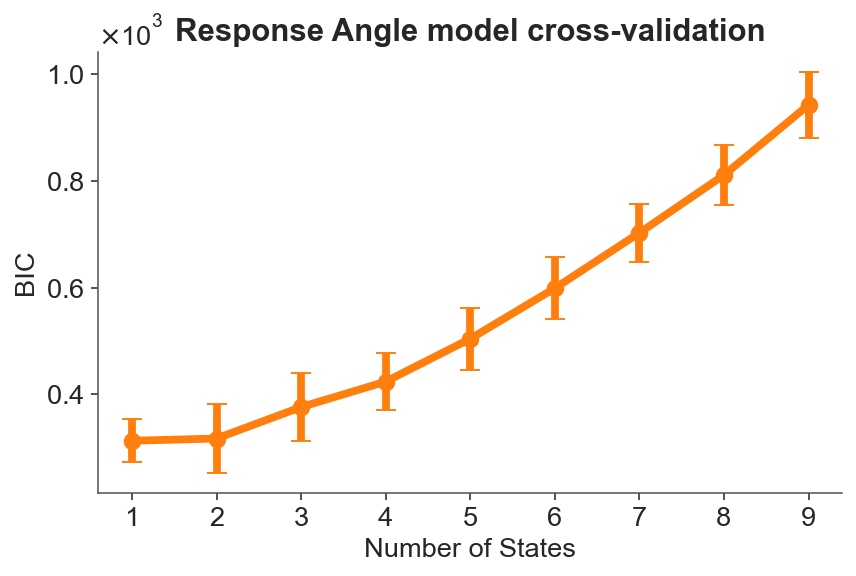

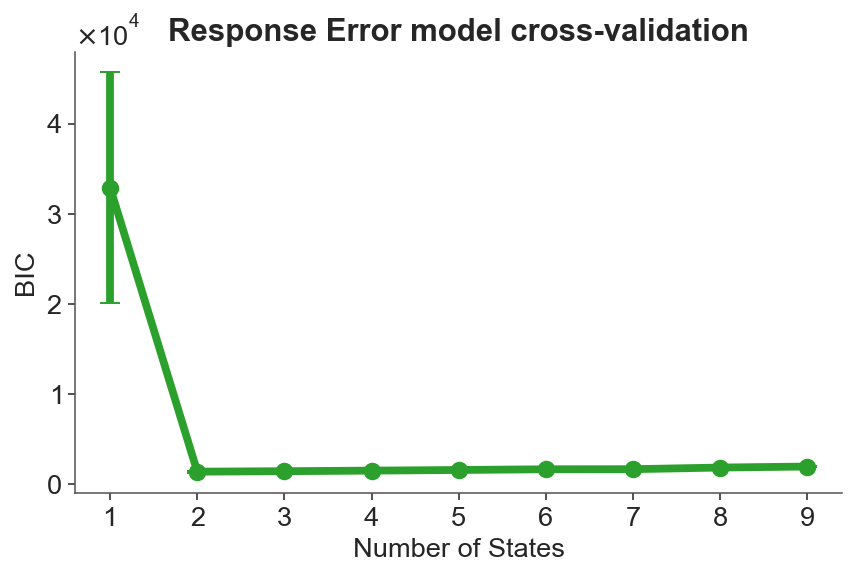

In [82]:
def join_crosvals(crossval_results, ost_crossval):
    full_crossval = crossval_results.copy()
    for idx in range(12):
        full_crossval[idx][1] = ost_crossval[idx][1].flatten()
        
    return full_crossval

rt_full_crossval = join_crosvals(rt_sub_crossval, rt_one_state)
ra_full_crossval = join_crosvals(ra_sub_crossval, ra_one_state)
re_full_crossval = join_crosvals(re_sub_crossval, re_one_state)

cvs = (rt_full_crossval, ra_full_crossval, re_full_crossval)
for i in range(0,3):
    all_cv, all_aic, all_bic = get_aic_bic(cvs[i], input_dims[i], emission_dims[i])
    
    plt.figure(figsize=(6, 4))
    x = np.arange(1, 10)
    y = all_bic.mean(axis=0)
    yerr = all_bic.std(axis=0)

    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt='-o',                  # line + circle markers
        color=colors[i],
        alpha=1,
        label="bic",
        linewidth=4,
        markersize=8,
        capsize=5                  # length of the little “T” on each error bar end
    )
    # scientific notation use everywhere
    fmt = ScalarFormatter(useMathText=True, useOffset=False)
    fmt.set_powerlimits((-1, 1))
    plt.gca().yaxis.set_major_formatter(fmt)
    
    
    plt.ylabel("BIC")
    plt.xticks(np.arange(1, 10))
    plt.xlabel("Number of States")
    plt.title(f"{titles[i]} model cross-validation")
    plt.show()
    
    # plot_mloocv(all_cv, all_aic, all_bic, titles[i])
    
    

## Params in general

In [14]:
rt_sub_params[1][2]

ParamsBlockHMMrt(initial=ParamsStandardHMMInitialState(probs=Array([0.0206118, 0.9793882], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.97591156, 0.02408849],
       [0.07275288, 0.9272471 ]], dtype=float32)), emissions=ParamsBlockHMMrtEmissions(w1=Array([[ 7.07736111e+00, -6.34536118e-05, -6.76801801e-03,
        -1.05796166e-01,  3.89942899e-02,  4.17409989e-04,
         6.88027576e-05,  8.82570239e-05],
       [ 6.84529543e+00,  4.75562498e-04, -1.95116326e-02,
        -6.51936457e-02,  2.03441232e-02, -6.97547337e-04,
        -1.18060340e-03, -2.69013166e-04]], dtype=float32), w2=Array([[26.85445],
       [14.27199]], dtype=float32)))

In [15]:
ra_sub_params[10][2]

ParamsBlockHMMra(initial=ParamsStandardHMMInitialState(probs=Array([0.6688756 , 0.33112445], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.8075132 , 0.1924868 ],
       [0.85125166, 0.1487483 ]], dtype=float32)), emissions=ParamsBlockHMMraEmissions(w1=Array([[ 1.2169991e+00,  1.2189917e-02, -1.9734599e-02, -1.0505580e-01,
         4.5628782e-02,  4.6028501e-05,  7.9089783e-02],
       [-1.5195693e-01,  1.0809963e+00,  3.4679051e-03,  7.4949609e-03,
         1.5634337e-02, -3.5972968e-02,  2.4270689e-02]], dtype=float32), w2=Array([[ 1.6295364],
       [21.511784 ]], dtype=float32)))

In [16]:
re_sub_params[8][2].emissions

ParamsBlockHMMreEremissions(w1=Array([[-4.0381365,  2.413112 , -0.0678158, -0.899985 ],
       [-4.2893734, -0.2969053,  1.1412518,  0.6748363]], dtype=float32), w2=Array([[38.628727],
       [ 8.46349 ]], dtype=float32))

In [17]:
ra_smoothed_posteriors[0].smoothed_probs.shape, ra_smoothed_posteriors[0].filtered_probs.shape

((24, 120, 2), (24, 120, 2))

## Params of rt model

In [18]:
rt_column_names = ['intercept', 'err', 'att', 'coh', 'exp', 'err*att', 'err*coh', 'err*exp']

In [19]:
all_state_0 = np.array([ rt_sub_params[i][2].emissions.w1[0] for i in range(12) ])
all_state_1 = np.array([ rt_sub_params[i][2].emissions.w1[1] for i in range(12) ])

all_concen_0 = np.array([ rt_sub_params[i][2].emissions.w2[0] for i in range(12) ])
all_concen_1 = np.array([ rt_sub_params[i][2].emissions.w2[1] for i in range(12) ])

trans_ra = [ rt_sub_params[i][2].transitions.transition_matrix for i in range(12) ]
trans_ra = np.array(trans_ra)

slow_transitions = []
fast_transitions = []

slow_params = []
fast_params = []

slow_concentration = []
fast_concentration = []

slow_post = []
fast_post = []

slow_filtered = []
fast_filtered = []

slow_ml = []
fast_ml = []

for i in range(12):
    # if the 1th (stimulus) absolute value is larger than then keep in engaged
    if np.exp(all_state_1[i][0]) > np.exp(all_state_0[i][0] ):
        
        # state 1 is the slow state, state 0 is the fast state
        
        slow_params.append(all_state_1[i])
        fast_params.append(all_state_0[i])
        
        slow_concentration.append(all_concen_1[i])
        fast_concentration.append(all_concen_0[i])
        
        slow_transitions.append(trans_ra[i][1])
        fast_transitions.append(trans_ra[i][0])
        
        slow_post.append(rt_smoothed_posteriors[i].smoothed_probs[:, :, 1])
        fast_post.append(rt_smoothed_posteriors[i].smoothed_probs[:, :, 0])
        
        slow_filtered.append(rt_smoothed_posteriors[i].filtered_probs[:, :, 1])
        fast_filtered.append(rt_smoothed_posteriors[i].filtered_probs[:, :, 0])
        
        slow_ml.append(rt_ml_states[i][1])
        fast_ml.append(rt_ml_states[i][0])

    else:
        slow_params.append(all_state_0[i])
        fast_params.append(all_state_1[i])
        
        slow_concentration.append(all_concen_0[i])
        fast_concentration.append(all_concen_1[i])
        
        slow_transitions.append(trans_ra[i][0])
        fast_transitions.append(trans_ra[i][1])
        
        slow_post.append(rt_smoothed_posteriors[i].smoothed_probs[:, :, 0])
        fast_post.append(rt_smoothed_posteriors[i].smoothed_probs[:, :, 1])
        
        slow_filtered.append(rt_smoothed_posteriors[i].filtered_probs[:, :, 0])
        fast_filtered.append(rt_smoothed_posteriors[i].filtered_probs[:, :, 1])

        slow_ml.append(rt_ml_states[i][0])
        fast_ml.append(rt_ml_states[i][1])

### Transitions

<Axes: ylabel='Transition Probability'>

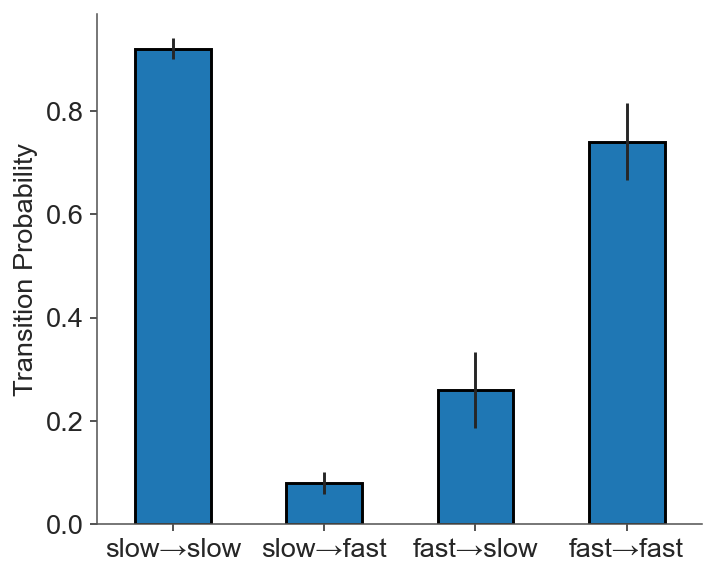

In [20]:
rt_trans_df = pd.DataFrame(np.concatenate([slow_transitions, fast_transitions], axis=-1), columns=["slow→slow", "slow→fast", "fast→slow", "fast→fast"])
# Now plotting the att, coh and exp during engaged and disengaged states
rt_trans_df.mean().plot.bar(
    figsize=(5, 4), 
    yerr=rt_trans_df.sem(),
    # title="Transition Probabilities",
    ylabel="Transition Probability",
    # xlabel="Covariates",
    color=colors[0],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    width=0.5,
)

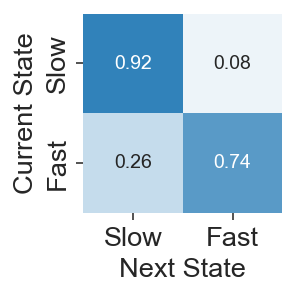

In [21]:
plt.figure(figsize=(2, 2))
sns.heatmap(
    data=rt_trans_df.mean().values.reshape(2, 2),
    annot=True,
    fmt=".2f",
    cmap=cmaps[0],
    cbar=False,
    xticklabels=["Slow", "Fast"],
    yticklabels=["Slow", "Fast"],
    vmin=0, vmax=1,
)
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.show()

### Params

In [22]:
slow_df = pd.DataFrame(np.array(slow_params), columns=rt_column_names)
slow_df.intercept = np.exp(slow_df.intercept)
for col in rt_column_names[1:]:
    slow_df[col] = (np.exp(slow_df[col]) - 1) * slow_df["intercept"]
slow_df

,intercept,err,att,coh,exp,err*att,err*coh,err*exp
0,541.991028,-0.015151,-48.367611,-2.376369,14.135133,0.139688,-0.012534,-0.539012
1,1184.837646,-0.075212,-7.991990,-118.948273,47.114647,0.494635,0.081639,0.104520
2,955.943726,-0.190594,-63.078083,-29.873755,-16.070951,-0.113388,-0.309964,0.780038
3,1001.447388,0.236376,-48.262852,-22.197083,11.837186,-0.233750,-0.021369,0.004656
4,1529.503174,0.189989,-70.915451,-142.344070,13.257468,0.203117,-0.025891,-0.351625
5,1205.178833,0.126285,-64.662895,-124.416786,-5.215383,0.083902,-0.539475,-0.250055
6,769.393616,-0.039026,-72.191002,12.203470,-15.153011,0.193160,0.190592,0.093553
7,1385.377441,-0.081749,-186.134216,-154.256912,28.518244,0.339053,0.261102,-0.124028
8,1142.639526,0.429480,-50.890633,-171.886810,-24.206455,-0.217873,0.720159,-0.484987
9,1231.764893,-0.414670,-52.484463,-99.229988,-0.135605,0.265483,0.263868,0.675160


In [23]:
fast_df = pd.DataFrame(np.array(fast_params), columns=rt_column_names)
fast_df.intercept = np.exp(fast_df.intercept)
for col in rt_column_names[1:]:
    fast_df[col] = (np.exp(fast_df[col]) - 1) * fast_df["intercept"]
fast_df

,intercept,err,att,coh,exp,err*att,err*coh,err*exp
0,205.838943,-0.239551,6.772783,-19.924332,10.942953,0.291093,0.159668,0.020906
1,939.450745,0.446957,-18.152550,-59.292484,19.308077,-0.655149,-1.108489,-0.252708
2,447.635864,-0.275590,-55.570915,-0.979893,60.869049,0.360516,-0.011500,-0.707612
3,524.218506,0.756712,-68.039322,-46.233028,43.069855,-0.582454,-0.344173,-0.755306
4,1015.386047,1.317195,-185.279266,16.091759,-35.615944,-0.888762,1.269746,-1.438662
5,956.332153,0.735210,-81.899101,-66.412674,-17.855825,-0.318412,-0.080544,0.701807
6,462.579926,0.172104,-66.520439,7.949423,22.400690,0.370953,0.103946,-0.078056
7,880.377380,0.061920,-48.267170,-52.882885,23.831541,0.572917,-0.266204,-0.506590
8,396.149078,1.979138,-49.503288,537.742737,-20.223625,-4.722914,-2.190988,-2.552681
9,396.314789,0.157655,132.882263,116.655884,20.988705,-0.493373,0.563531,0.702761


#### Fast params

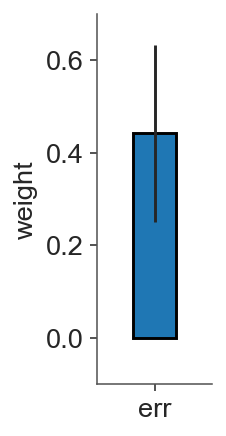

In [24]:
cols = ["err"]
ax = fast_df[cols].mean().plot.bar(
    yerr=fast_df[cols].sem(),
    ylabel="weight",
    color=colors[0],
    figsize=(1.5, 3),
    **bar_kwargs,
)
ax.set(ylim=(-0.1, 0.7))
# ax = move_ax_to_right(ax)
plt.show()

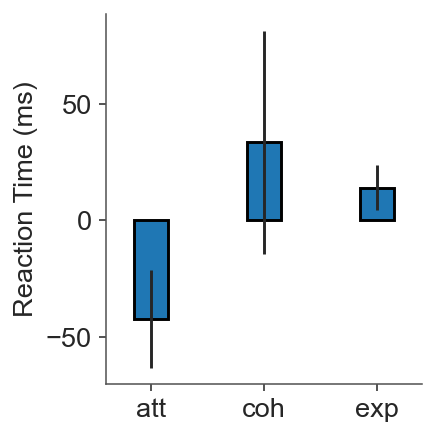

In [25]:
cols = ['att', 'coh', 'exp']
ax = fast_df[cols].mean().plot.bar(
    yerr=fast_df[cols].sem(),
    ylabel="Reaction Time (ms)",
    color=colors[0],
    figsize=(3, 3),
    **bar_kwargs,
)
# ax = move_ax_to_right(ax)

plt.show()

In [26]:
fast_bc = pd.DataFrame(np.array([fast_df.intercept.values, np.array(fast_concentration).flatten()]).T, columns=["intercept", "concentration"])

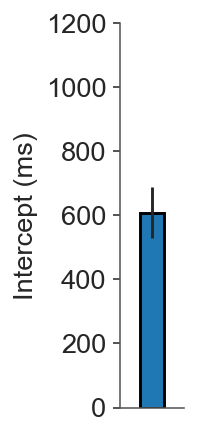

In [27]:
cols = ['intercept']
ax = fast_bc[cols].mean().plot.bar(
    yerr=fast_bc[cols].sem(),
    color=colors[0],
    figsize=(1.3, 3),
    ylabel="Intercept (ms)",
    **bar_kwargs,
)
# ax = move_ax_to_right(ax)
ax.set(ylim=(0, 1200), xticks=[])
plt.show()

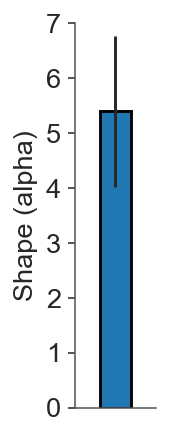

In [28]:
cols = ['concentration']
ax = fast_bc[cols].mean().plot.bar(
    yerr=fast_bc[cols].sem(),
    color=colors[0],
    figsize=(1.1, 3),
    ylabel="Shape (alpha)",
    **bar_kwargs,
)
# ax = move_ax_to_right(ax)
ax.set(ylim=(0, 7), xticks=[])
plt.show()

#### Slow Params

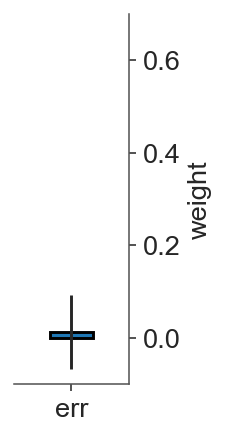

In [29]:
cols = ["err"]
ax = slow_df[cols].mean().plot.bar(
    yerr=slow_df[cols].sem(),
    ylabel="weight",
    color=colors[0],
    figsize=(1.5, 3),
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
ax.set(ylim=(-0.1, 0.7))
plt.show()


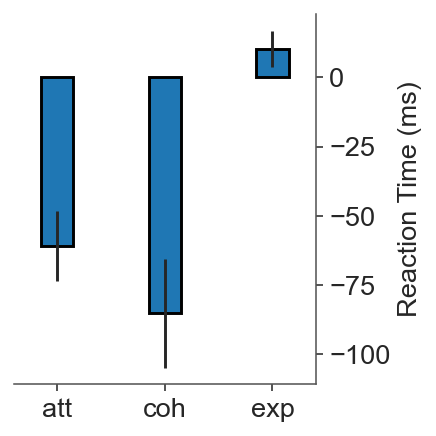

In [30]:
cols = ["att", "coh", "exp"]
ax = slow_df[cols].mean().plot.bar(
    yerr=slow_df[cols].sem(),
    ylabel="Reaction Time (ms)",
    color=colors[0],
    figsize=(3, 3),
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
plt.show()

In [31]:
slow_bc = pd.DataFrame(np.array([slow_df.intercept.values, np.array(slow_concentration).flatten()]).T, columns=["intercept", "concentration"])

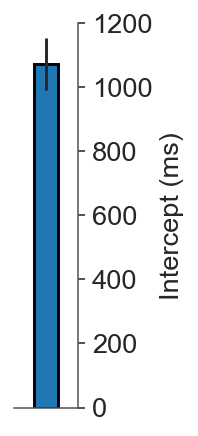

In [32]:
cols = ['intercept']
ax = slow_bc[cols].mean().plot.bar(
    yerr=slow_bc[cols].sem(),
    color=colors[0],
    figsize=(1.3, 3),
    ylabel="Intercept (ms)",
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
ax.set(ylim=(0, 1200), xticks=[])
plt.show()

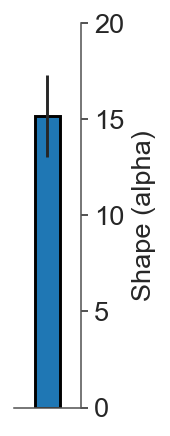

In [33]:
cols = ['concentration']
ax = slow_bc[cols].mean().plot.bar(
    yerr=slow_bc[cols].sem(),
    color=colors[0],
    figsize=(1.1, 3),
    ylabel="Shape (alpha)",
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
ax.set(ylim=(0, 20), xticks=[])
plt.show()

### Posteriors

In [34]:
slow_post = np.array(slow_post)
fast_post = np.array(fast_post)

slow_filtered = np.array(slow_filtered)
fast_filtered = np.array(fast_filtered)

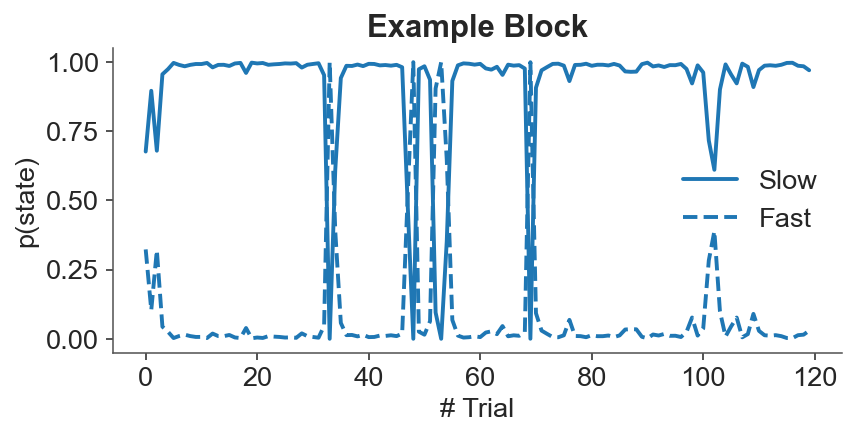

In [36]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = plot_block(slow_post[9,3], None, 'Slow', colors[0], line_style='-', ax=ax)
ax = plot_block(fast_post[9,3], None, 'Fast', colors[0], line_style='--', ax=ax)

# ax.set(ylim=(0, 1))
ax.set(ylabel="p(state)", xlabel="# Trial", title="Example Block")
ax.legend(loc='center right')
plt.show()

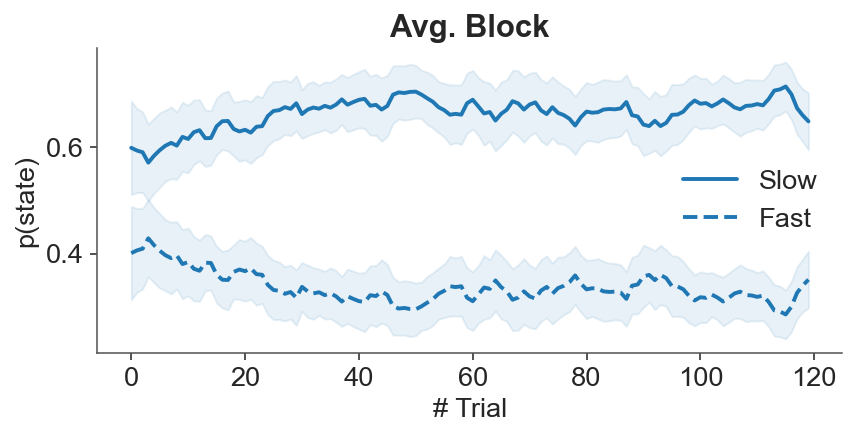

In [37]:
slow_mean = slow_post.mean(1).mean(0)
slow_sem = slow_post.mean(1).std(0) / np.sqrt(slow_post.mean(1).shape[0])

fast_mean = fast_post.mean(1).mean(0)
fast_sem = fast_post.mean(1).std(0) / np.sqrt(fast_post.mean(1).shape[0])

fig, ax = plt.subplots(figsize=(6, 3))
# plot the mean and sem of slow state
ax = plot_block(slow_mean, slow_sem, 'Slow', colors[0], line_style='-', ax=ax)
ax = plot_block(fast_mean, fast_sem, 'Fast', colors[0], line_style='--', ax=ax)

# ax.set(ylim=(0, 1))
ax.set(ylabel="p(state)", xlabel="# Trial", title="Avg. Block")
ax.legend(loc='center right')
plt.show()

## Params of RA model

In [38]:
# bar plot with 2 values

In [39]:
for i in range(12):
    print(ra_sub_params[i][2].emissions.w1[0][:2], ra_sub_params[i][2].emissions.w1[1][:2])
    print(ra_sub_params[i][2].emissions.w2[0], ra_sub_params[i][2].emissions.w2[1])


[ 2.2945657  -0.40180647] [0.18179953 0.8574486 ]
[3.0732875] [39.24268]
[ 2.9333825 -0.8559222] [-0.0158453  0.9619597]
[11.740901] [26.242231]
[ 1.5867318  -0.03192801] [-0.1343372  1.0255026]
[2.267159] [43.033657]
[ 1.7921386  -0.10803896] [-0.0992438  1.0383189]
[2.3017797] [44.466984]
[ 2.0333798  -0.23348808] [0.14848697 0.92660195]
[3.1388686] [28.740854]
[ 2.376463 -0.645974] [0.20573525 0.8219863 ]
[5.4974236] [24.64556]
[ 2.3916075  -0.45641646] [0.12237941 0.9075974 ]
[3.084517] [28.550446]
[ 1.5608802 -0.0219167] [0.03684719 0.96236074]
[2.3025007] [45.109024]
[ 1.4158689  -0.05450052] [0.02888204 0.88818026]
[4.6993365] [30.34792]
[ 1.3468556  -0.16053526] [0.04350015 0.9001435 ]
[2.4532974] [36.25643]
[1.216999   0.01218992] [-0.15195693  1.0809963 ]
[1.6295364] [21.511784]
[ 1.97538   -0.1783613] [0.03669604 0.96550894]
[2.3337507] [35.999897]


In [40]:
# RA features: [1, stim, p_stim, p_resp, Att, Coh, Exp]


In [41]:
all_state_0 = np.array([ ra_sub_params[i][2].emissions.w1[0] for i in range(12) ])
all_state_1 = np.array([ ra_sub_params[i][2].emissions.w1[1] for i in range(12) ])

all_concen_0 = np.array([ ra_sub_params[i][2].emissions.w2[0] for i in range(12) ])
all_concen_1 = np.array([ ra_sub_params[i][2].emissions.w2[1] for i in range(12) ])

trans_ra = [ ra_sub_params[i][2].transitions.transition_matrix for i in range(12) ]
trans_ra = np.array(trans_ra)

engaged_transitions = []
disengaged_transitions = []

engaged_params = []
disengaged_params = []

engaged_concentration = []
disengaged_concentration = []

engaged_post = []
disengaged_post = []

for i in range(12):
    # if the 1th (stimulus) absolute value is larger than then keep in engaged
    if np.abs(all_state_1[i][1])* all_concen_1[i] > np.abs(all_state_0[i][1])* all_concen_0[i]:
        engaged_params.append(all_state_1[i])
        disengaged_params.append(all_state_0[i])
        
        engaged_concentration.append(all_concen_1[i])
        disengaged_concentration.append(all_concen_0[i])
        
        engaged_transitions.append(trans_ra[i][1])
        disengaged_transitions.append(trans_ra[i][0])
        
        engaged_post.append(ra_smoothed_posteriors[i].smoothed_probs[:, :, 1])
        disengaged_post.append(ra_smoothed_posteriors[i].smoothed_probs[:, :, 0])
    else:
        engaged_params.append(all_state_0[i])
        disengaged_params.append(all_state_1[i])
        
        engaged_concentration.append(all_concen_0[i])
        disengaged_concentration.append(all_concen_1[i])
        
        engaged_transitions.append(trans_ra[i][0])
        disengaged_transitions.append(trans_ra[i][1])
        
        engaged_post.append(ra_smoothed_posteriors[i].smoothed_probs[:, :, 0])
        disengaged_post.append(ra_smoothed_posteriors[i].smoothed_probs[:, :, 1])


In [42]:
# engaged_transitions

In [43]:
# disengaged_transitions

In [44]:
np.array(engaged_concentration).flatten()

array([39.24268 , 26.242231, 43.033657, 44.466984, 28.740854, 24.64556 ,
       28.550446, 45.109024, 30.34792 , 36.25643 , 21.511784, 35.999897],
      dtype=float32)

In [45]:
np.array(disengaged_concentration).flatten()

array([ 3.0732875, 11.740901 ,  2.267159 ,  2.3017797,  3.1388686,
        5.4974236,  3.084517 ,  2.3025007,  4.6993365,  2.4532974,
        1.6295364,  2.3337507], dtype=float32)

(-0.5, 1.5)

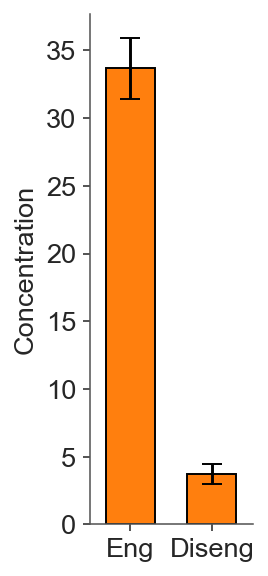

In [46]:
# make 2 bars with these values and error bars
# first bar is engaged, second is disengaged

plt.figure(figsize=(1.8, 4))

bar_y = [np.array(engaged_concentration).flatten().mean(), np.array(disengaged_concentration).flatten().mean()]
# bar_yerr = [np.array(engaged_concentration).flatten().std(), np.array(disengaged_concentration).flatten().std()]
bar_yerr_sem = [np.array(engaged_concentration).flatten().std() / np.sqrt(12),
                np.array(disengaged_concentration).flatten().std() / np.sqrt(12)]
plt.bar(
    ["Eng", "Diseng"],
    bar_y,
    yerr=bar_yerr_sem,
    color=colors[1],
    edgecolor='black',
    alpha=1,
    capsize=5,
    width=0.6,
)
plt.ylabel("Concentration")
plt.xlim(-0.5, 1.5)


### Transitions

<Axes: ylabel='Transition Probability'>

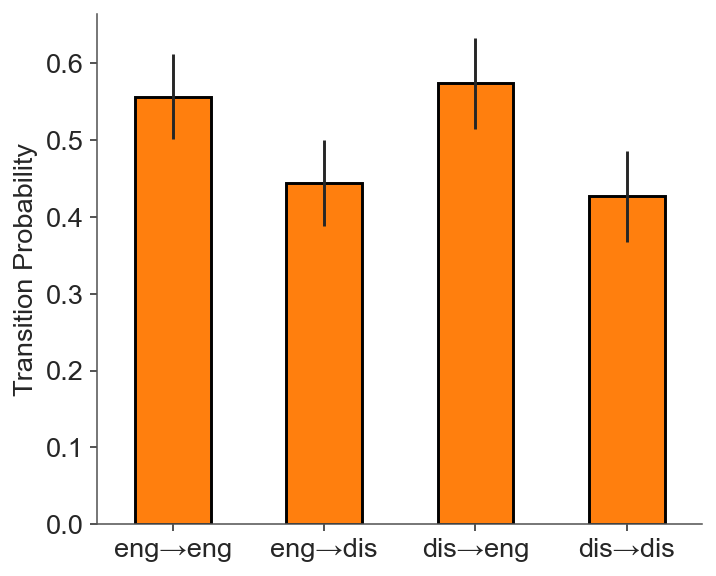

In [83]:
ra_trans_df = pd.DataFrame(np.concatenate([engaged_transitions, disengaged_transitions], axis=-1), columns=["eng→eng", "eng→dis", "dis→eng", "dis→dis"])
# Now plotting the att, coh and exp during engaged and disengaged states
ra_trans_df.mean().plot.bar(
    figsize=(5, 4), 
    yerr=ra_trans_df.sem(),
    # title="Transition Probabilities",
    ylabel="Transition Probability",
    # xlabel="Covariates",
    color=colors[1],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    width=0.5,
)

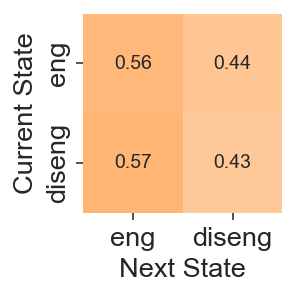

In [85]:

# plot that above in a heatmap
plt.figure(figsize=(2, 2))
sns.heatmap(
    data=ra_trans_df.mean().values.reshape(2, 2),
    annot=True,
    fmt=".2f",
    cmap=cmaps[1],
    cbar=False,
    xticklabels=["eng", "diseng"],
    yticklabels=["eng", "diseng"],
    vmin=0, vmax=1,
)
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.show()

### Params

In [86]:
column_names = [ "intercept", "stim", "p_stim", "p_resp", "Att", "Coh", "Exp"]

In [88]:
engaged_df = pd.DataFrame(engaged_params, columns=column_names) * (180 / np.pi)
engaged_df

,intercept,stim,p_stim,p_resp,Att,Coh,Exp
0,10.416346,49.128185,0.648119,0.831157,-0.615855,0.020408,2.463604
1,-0.907869,55.116234,-0.262701,0.772323,-0.625075,0.775056,-0.206571
2,-7.696955,58.756969,0.734889,1.620170,1.087732,0.739764,2.517816
3,-5.686251,59.491291,0.952523,1.296313,0.573751,-1.043002,0.732178
4,8.507677,53.090382,-1.124253,0.305113,0.603034,-0.574109,-2.857196
5,11.787762,47.096348,-0.055991,0.407324,-0.330639,0.705257,2.180663
6,7.011824,52.001503,0.372157,-0.417448,1.376373,1.336114,-0.389119
7,2.111189,55.139210,0.567048,0.975440,-0.464241,0.497453,1.105062
8,1.654819,50.888981,-2.897559,5.904997,0.588819,-0.229595,0.173166
9,2.492375,51.574425,0.548535,0.364663,-0.574548,0.776392,0.321393


In [90]:
disengaged_df = pd.DataFrame(disengaged_params, columns=column_names) * (180 / np.pi)
disengaged_df

,intercept,stim,p_stim,p_resp,Att,Coh,Exp
0,131.468933,-23.021816,4.934625,-17.162519,-4.559101,-0.731367,1.801035
1,168.070435,-49.040733,-2.286829,3.741226,1.645331,0.190183,-2.269308
2,90.913033,-1.829340,0.933993,1.567216,-2.060564,0.081127,-1.648477
3,102.681976,-6.190176,2.523583,-6.698874,-2.720863,-0.082179,-1.435511
4,116.504082,-13.377882,-1.389544,-7.427882,-0.402014,-3.850831,3.237653
5,136.161301,-37.011581,0.070694,0.787926,-1.711498,-2.112866,3.006582
6,137.029022,-26.150738,-1.454133,-10.017094,4.557416,-3.300185,-0.780139
7,89.431847,-1.255734,0.581126,-3.799382,-1.430549,2.137933,0.000324
8,81.123314,-3.122650,0.682917,3.521875,1.262622,0.300776,-0.593185
9,77.169144,-9.197993,-0.666429,7.721542,-2.705316,0.165408,2.870282


#### Engaged Params

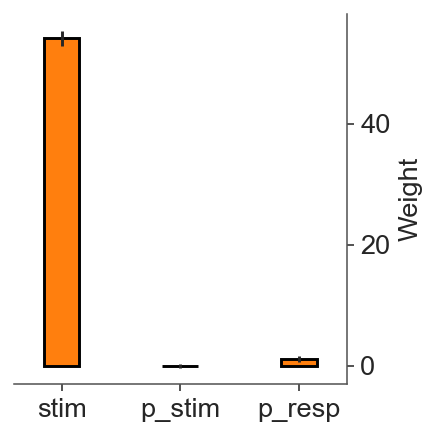

In [356]:
cols = ["stim", "p_stim", "p_resp"]
ax = engaged_df[cols].mean().plot.bar(
    figsize=(3, 3), 
    yerr=engaged_df[cols].sem(),
    ylabel="Weight",
    color=colors[1],
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
plt.show()

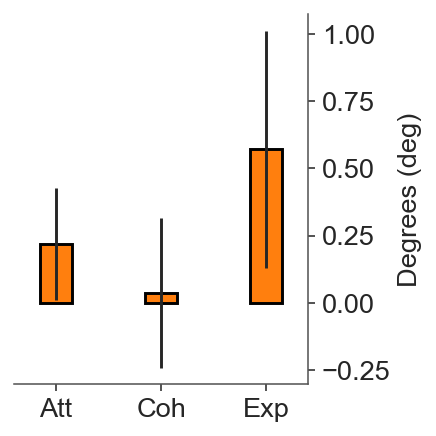

In [101]:
cols = ["Att", "Coh", "Exp"]
ax = engaged_df[cols].mean().plot.bar(
    figsize=(3, 3), 
    yerr=engaged_df[cols].sem(),
    ylabel="Degrees (deg)",
    color=colors[1],
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
plt.show()

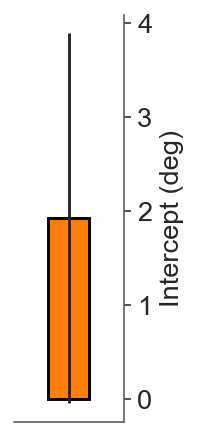

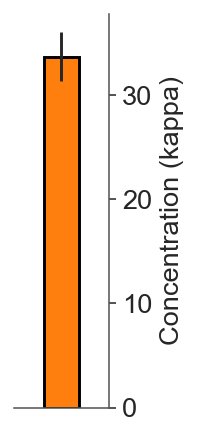

In [117]:
engaged_bc = pd.DataFrame(np.array([engaged_df.intercept.values, np.array(engaged_concentration).flatten()]).T, columns=["intercept", "concentration"])

cols = ['intercept']
ax = engaged_bc[cols].mean().plot.bar(
    yerr=engaged_bc[cols].sem(),
    color=colors[1],
    figsize=(1.3, 3),
    ylabel="Intercept (deg)",
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
ax.set(xticks=[])
plt.show()

cols = ["concentration"]
ax = engaged_bc[cols].mean().plot.bar(
    yerr=engaged_bc[cols].sem(),
    color=colors[1],
    figsize=(1.3, 3),
    ylabel="Concentration (kappa)",
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
ax.set(xticks=[])
plt.show()

#### Disengaged Params

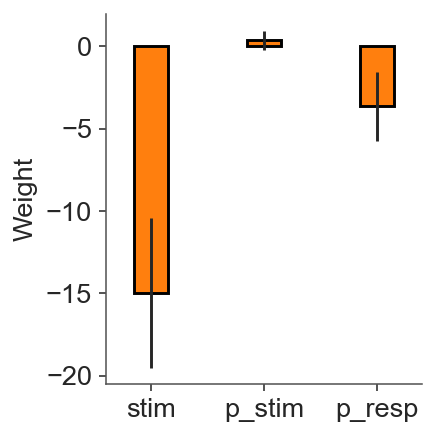

In [357]:
cols = ["stim", "p_stim", "p_resp"]
ax = disengaged_df[cols].mean().plot.bar(
    figsize=(3, 3), 
    yerr=disengaged_df[cols].sem(),
    ylabel="Weight",
    color=colors[1],
    **bar_kwargs,
)
plt.show()

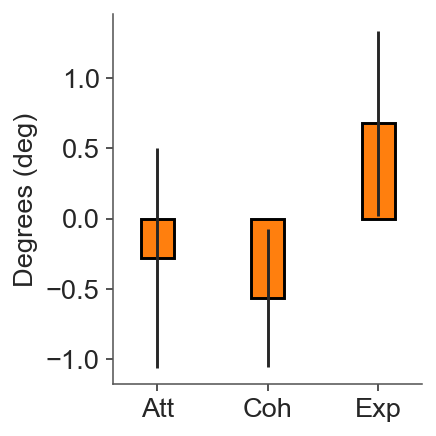

In [103]:
cols = ["Att", "Coh", "Exp"]
ax = disengaged_df[cols].mean().plot.bar(
    figsize=(3, 3), 
    yerr=disengaged_df[cols].sem(),
    ylabel="Degrees (deg)",
    color=colors[1],
    **bar_kwargs,
)

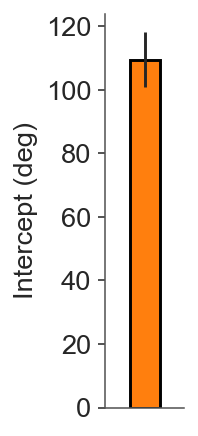

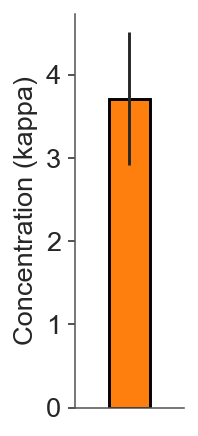

In [137]:
disengaged_bc = pd.DataFrame(np.array([disengaged_df.intercept.values, np.array(disengaged_concentration).flatten()]).T, columns=["intercept", "concentration"])

cols = ['intercept']
ax = disengaged_bc[cols].mean().plot.bar(
    yerr=disengaged_bc[cols].sem(),
    color=colors[1],
    figsize=(1.3, 3),
    ylabel="Intercept (deg)",
    **bar_kwargs,
)
ax.set(xticks=[])
plt.show()

cols = ["concentration"]
ax = disengaged_bc[cols].mean().plot.bar(
    yerr=disengaged_bc[cols].sem(),
    color=colors[1],
    figsize=(1.3, 3),
    ylabel="Concentration (kappa)",
    **bar_kwargs,
)
ax.set(xticks=[])
plt.show()

### Posteriors

In [142]:
engaged_post = np.array(engaged_post)
disengaged_post = np.array(disengaged_post)

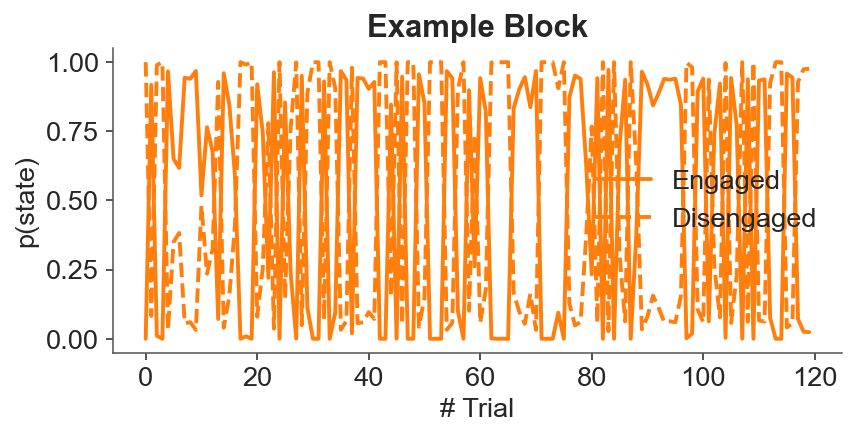

In [145]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = plot_block(engaged_post[9,3], None, 'Engaged', colors[1], line_style='-', ax=ax)
ax = plot_block(disengaged_post[9,3], None, 'Disengaged', colors[1], line_style='--', ax=ax)

# ax.set(ylim=(0, 1))
ax.set(ylabel="p(state)", xlabel="# Trial", title="Example Block")
ax.legend(loc='center right')
plt.show()

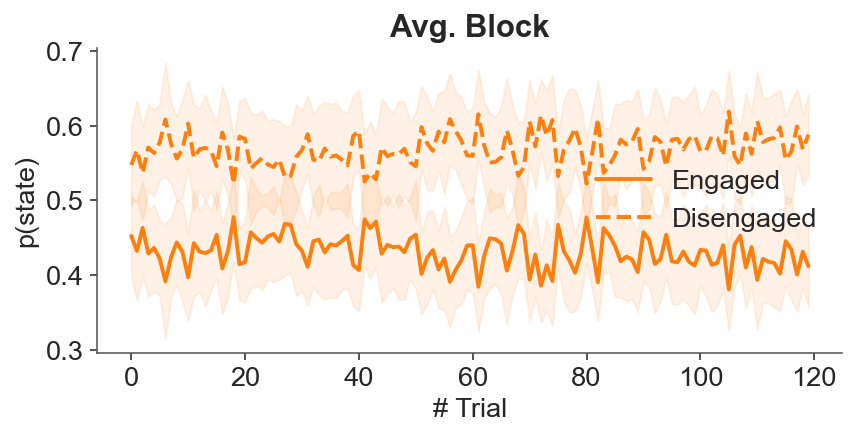

In [151]:
engaged_mean = engaged_post.mean(1).mean(0)
engaged_sem = engaged_post.mean(1).std(0) / np.sqrt(engaged_post.mean(1).shape[0])

disengaged_mean = disengaged_post.mean(1).mean(0)
disengaged_sem = disengaged_post.mean(1).std(0) / np.sqrt(disengaged_post.mean(1).shape[0])

fig, ax = plt.subplots(figsize=(6, 3))
# plot the mean and sem of engaged state
ax = plot_block(engaged_mean, engaged_sem, 'Engaged', colors[1], line_style='-', ax=ax)
ax = plot_block(disengaged_mean, disengaged_sem, 'Disengaged', colors[1], line_style='--', ax=ax)

# ax.set(ylim=(0, 1))
ax.set(ylabel="p(state)", xlabel="# Trial", title="Avg. Block")
ax.legend(loc='center right')
plt.show()

## Now RE model

In [118]:
def wrap_deg(theta):
    return ((theta + 180) % 360) - 180

def wrap_df_deg(df: pd.DataFrame) -> pd.DataFrame:
    """
    Wrap each column of df (angles in degrees) into [-180, +180].
    """
    df_w = df.copy()
    for col in df_w.columns:
        df_w[col] = ((df_w[col] + 180) % 360) - 180
    return df_w

def to_0_360(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remap angles from [-180,180] (0°=front, +90=left, -90=right)
    into [0,360) with 0°=right and increasing CCW:
      new = (old + 90) % 360
    """
    df2 = df.copy()
    for col in df2.columns:
        df2[col] = (df2[col] + 90) % 360
    return df2

In [119]:
for i in range(12):
    print(re_sub_params[i][2].emissions.w1[0][:2], re_sub_params[i][2].emissions.w1[1][:2])
    print(re_sub_params[i][2].emissions.w2[0], re_sub_params[i][2].emissions.w2[1])


[2.4762511  0.20049171] [-0.75209016 -1.5311499 ]
[39.361927] [0.27487665]
[5.0005503 1.4208349] [-3.0588639  -0.19382332]
[39.302395] [7.9332366]
[11.03364   -1.9099244] [-3.0864286  -0.45081913]
[39.253513] [0.00013571]
[ 4.227769  -2.4305587] [-1.3579284 -0.8394315]
[39.26289] [3.324426e-09]
[0.78508013 0.9488984 ] [ 0.12580036 -1.5638459 ]
[39.13014] [6.283627e-05]
[-5.357464  -0.1986668] [-1.8062711  -0.92341495]
[39.265102] [9.360545]
[-2.403314   6.2670093] [-0.76102215  3.7251005 ]
[39.2783] [0.13769992]
[5.8386264  0.15421735] [ 1.5884264  -0.07919041]
[39.34502] [3.4789965]
[-4.0381365  2.413112 ] [-4.2893734 -0.2969053]
[38.628727] [8.46349]
[ 0.09916797 -0.5297079 ] [-4.065119   -0.29898885]
[39.302532] [7.0444517]
[-22.514656   -4.2425475] [-2.1897016 -1.6669164]
[39.28348] [0.00017969]
[9.700191   0.96035886] [-1.903947  -0.9863843]
[39.373833] [4.4310303]


In [153]:
all_state_0 = np.array([ re_sub_params[i][2].emissions.w1[0] for i in range(12) ])
all_state_1 = np.array([ re_sub_params[i][2].emissions.w1[1] for i in range(12) ])

all_concen_0 = np.array([ re_sub_params[i][2].emissions.w2[0] for i in range(12) ])
all_concen_1 = np.array([ re_sub_params[i][2].emissions.w2[1] for i in range(12) ])

trans_ra = [ re_sub_params[i][2].transitions.transition_matrix for i in range(12) ]
trans_ra = np.array(trans_ra)

accurate_transitions = []
erratic_transitions = []

accurate_params = []
erratic_params = []

accurate_concentration = []
erratic_concentration = []

accurate_post = []
erratic_post = []

for i in range(12):
    # if the 1th (stimulus) absolute value is larger than then keep in accurate
    if all_concen_1[i] < all_concen_0[i]:
        accurate_params.append(all_state_1[i])
        erratic_params.append(all_state_0[i])
        
        accurate_concentration.append(all_concen_1[i])
        erratic_concentration.append(all_concen_0[i])
        
        accurate_transitions.append(trans_ra[i][1])
        erratic_transitions.append(trans_ra[i][0])
        
        accurate_post.append(re_smoothed_posteriors[i].smoothed_probs[:, :, 1])
        erratic_post.append(re_smoothed_posteriors[i].smoothed_probs[:, :, 0])
    else:
        accurate_params.append(all_state_0[i])
        erratic_params.append(all_state_1[i])
        
        accurate_concentration.append(all_concen_0[i])
        erratic_concentration.append(all_concen_1[i])
        
        accurate_transitions.append(trans_ra[i][0])
        erratic_transitions.append(trans_ra[i][1])
        
        accurate_post.append(re_smoothed_posteriors[i].smoothed_probs[:, :, 0])
        erratic_post.append(re_smoothed_posteriors[i].smoothed_probs[:, :, 1])
    

### Transitions

<Axes: ylabel='Transition Probability'>

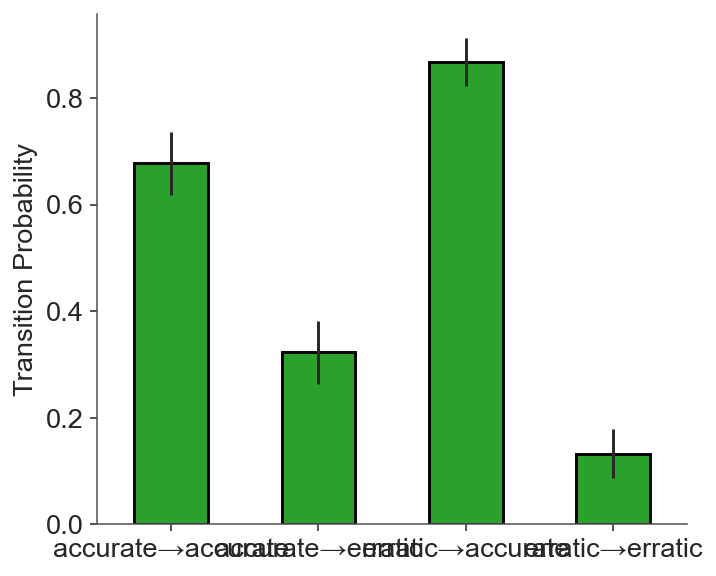

In [122]:
re_trans_df = pd.DataFrame(np.concatenate([accurate_transitions, erratic_transitions], axis=-1), columns=["accurate→accurate", "accurate→erratic", "erratic→accurate", "erratic→erratic"])
# Now plotting the att, coh and exp during engaged and disengaged states
re_trans_df.mean().plot.bar(
    figsize=(5, 4), 
    yerr=re_trans_df.sem(),
    # title="Transition Probabilities",
    ylabel="Transition Probability",
    # xlabel="Covariates",
    color=colors[2],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    width=0.5,
)

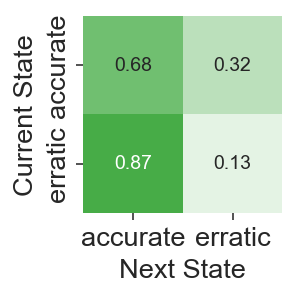

In [123]:
# plot that above in a heatmap
plt.figure(figsize=(2, 2))
sns.heatmap(
    data=re_trans_df.mean().values.reshape(2, 2),
    annot=True,
    fmt=".2f",
    cmap=cmaps[2],
    cbar=False,
    xticklabels=["accurate", "erratic"],
    yticklabels=["accurate", "erratic"],
    vmin=0, vmax=1,
)
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.show()

### Params

In [125]:
column_names = [ "intercept", "Att", "Coh", "Exp"]

In [126]:
accurate_df = pd.DataFrame(accurate_params, columns=column_names)
accurate_df

,intercept,Att,Coh,Exp
0,-0.752090,-1.531150,0.544204,1.577096
1,-3.058864,-0.193823,0.971865,0.189562
2,-3.086429,-0.450819,2.280205,2.594775
3,-1.357928,-0.839432,-0.211647,-0.179875
4,0.125800,-1.563846,0.053162,0.821707
5,-1.806271,-0.923415,0.944921,1.086497
6,-0.761022,3.725101,-1.276901,1.683361
7,1.588426,-0.079190,-0.229771,0.606284
8,-4.289373,-0.296905,1.141252,0.674836
9,-4.065119,-0.298989,1.505975,-0.654817


In [132]:
# np.array(accurate_concentration)

In [128]:
erratic_df = pd.DataFrame(erratic_params, columns=column_names) * (180 / np.pi)
erratic_df

,intercept,Att,Coh,Exp
0,141.878738,11.487329,107.433060,-15.027245
1,286.510437,81.407845,-95.501633,-5.780699
2,632.181030,-109.430611,-252.662064,36.120590
3,242.233322,-139.260757,-105.431168,-87.487442
4,44.981777,54.367874,-193.895676,-118.858322
5,-306.960083,-11.382769,194.141785,202.987885
6,-137.699753,359.073181,-7.219742,-71.329033
7,334.528656,8.836003,-32.626308,124.027222
8,-231.368179,138.261124,-3.885559,-51.565342
9,5.681906,-30.350027,-173.333618,89.026443


In [131]:
# np.array(erratic_concentration)

#### Accurate

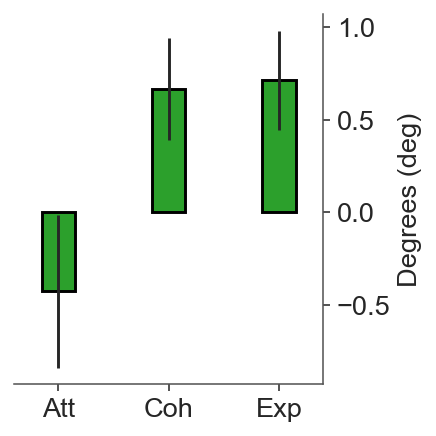

In [136]:
cols = ["Att", "Coh", "Exp"]
ax = accurate_df[cols].mean().plot.bar(
    figsize=(3, 3), 
    yerr=accurate_df[cols].sem(),
    ylabel="Degrees (deg)",
    color=colors[2],
    **bar_kwargs,
)
ax = move_ax_to_right(ax)

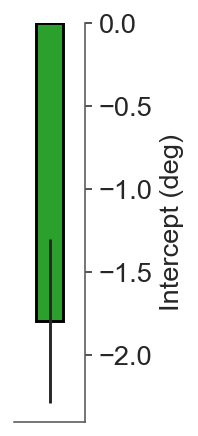

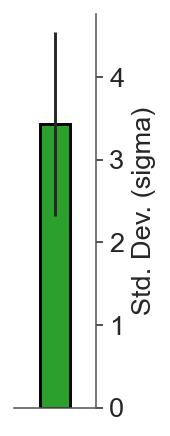

In [141]:
accurate_bc = pd.DataFrame(np.array([accurate_df.intercept.values, np.array(accurate_concentration).flatten()]).T, columns=["intercept", "concentration"])

cols = ['intercept']
ax = accurate_bc[cols].mean().plot.bar(
    yerr=accurate_bc[cols].sem(),
    color=colors[2],
    figsize=(1.3, 3),
    ylabel="Intercept (deg)",
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
ax.set(xticks=[])
plt.show()

cols = ["concentration"]
ax = accurate_bc[cols].mean().plot.bar(
    yerr=accurate_bc[cols].sem(),
    color=colors[2],
    figsize=(1.1, 3),
    ylabel="Std. Dev. (sigma)",
    **bar_kwargs,
)
ax = move_ax_to_right(ax)
ax.set(xticks=[])
plt.show()

#### Erratic

<Axes: ylabel='Degrees (deg)'>

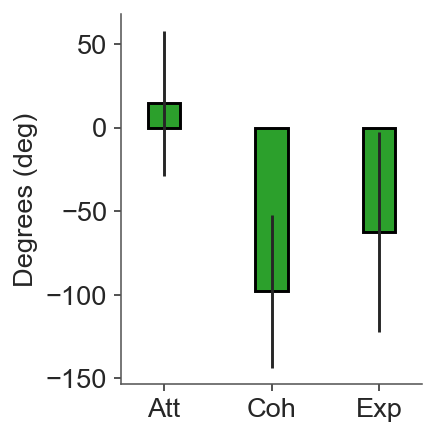

In [75]:
erratic_df[["Att", "Coh", "Exp"]].mean().plot.bar(
    figsize=(3, 3), 
    yerr=erratic_df[["Att", "Coh", "Exp"]].sem(),
    # title="erratic",
    ylabel="Degrees (deg)",
    # xlabel="Covariates",
    color=colors[2],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    width=0.3,
)

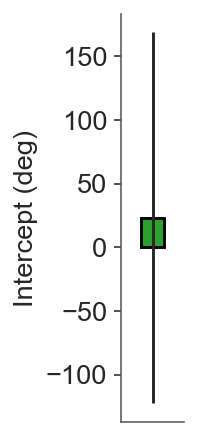

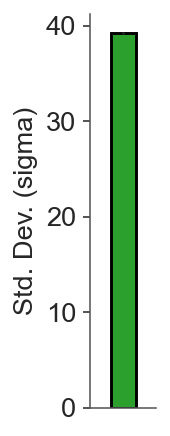

In [358]:
erratic_bc = pd.DataFrame(np.array([erratic_df.intercept.values, np.array(erratic_concentration).flatten()]).T, columns=["intercept", "concentration"])

cols = ['intercept']
ax = erratic_bc[cols].mean().plot.bar(
    yerr=erratic_bc[cols].sem(),
    color=colors[2],
    figsize=(1.3, 3),
    ylabel="Intercept (deg)",
    **bar_kwargs,
)
# ax = move_ax_to_right(ax)
ax.set(xticks=[])
plt.show()

cols = ["concentration"]
ax = erratic_bc[cols].mean().plot.bar(
    yerr=erratic_bc[cols].sem(),
    color=colors[2],
    figsize=(1.1, 3),
    ylabel="Std. Dev. (sigma)",
    **bar_kwargs,
)
# ax = move_ax_to_right(ax)
ax.set(xticks=[])
plt.show()

### Posteriors

In [154]:
accurate_post = np.array(accurate_post)
erratic_post = np.array(erratic_post)

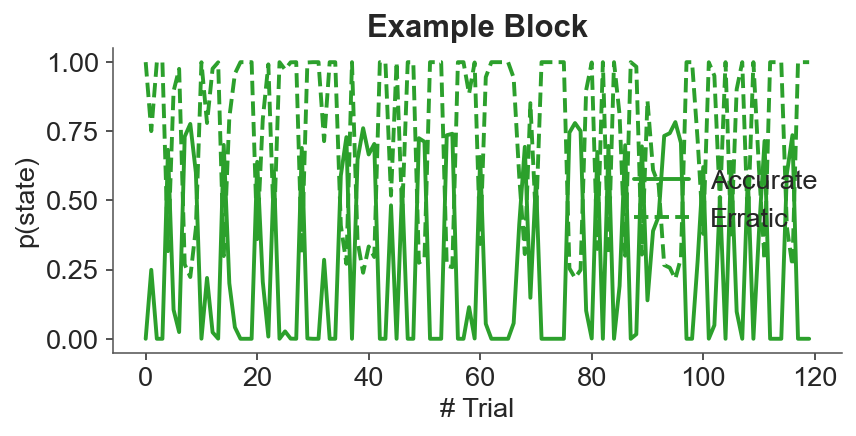

In [155]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = plot_block(accurate_post[9,3], None, 'Accurate', colors[2], line_style='-', ax=ax)
ax = plot_block(erratic_post[9,3], None, 'Erratic', colors[2], line_style='--', ax=ax)

# ax.set(ylim=(0, 1))
ax.set(ylabel="p(state)", xlabel="# Trial", title="Example Block")
ax.legend(loc='center right')
plt.show()

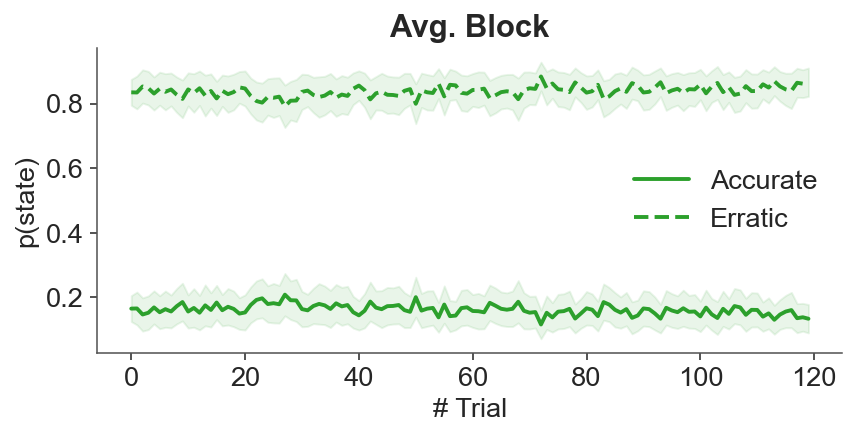

In [156]:
accurate_mean = accurate_post.mean(1).mean(0)
accurate_sem = accurate_post.mean(1).std(0) / np.sqrt(accurate_post.mean(1).shape[0])

erratic_mean = erratic_post.mean(1).mean(0)
erratic_sem = erratic_post.mean(1).std(0) / np.sqrt(erratic_post.mean(1).shape[0])

fig, ax = plt.subplots(figsize=(6, 3))
# plot the mean and sem of accurate state
ax = plot_block(accurate_mean, accurate_sem, 'Accurate', colors[2], line_style='-', ax=ax)
ax = plot_block(erratic_mean, erratic_sem, 'Erratic', colors[2], line_style='--', ax=ax)

# ax.set(ylim=(0, 1))
ax.set(ylabel="p(state)", xlabel="# Trial", title="Avg. Block")
ax.legend(loc='center right')
plt.show()

## Example viz

In [310]:
def wrap_angles(angles, threshold=180):
    """
    Map any angle > threshold into the negative side by subtracting 360,
    so that e.g. 350° → -10° and will plot across the 0° boundary.
    """
    return np.where(angles > threshold, angles - 360, angles)

def plot_block(target, resp, y_min=-100, y_max=180, y_step=25, ax=None, figsize=(20,4)):
    # wrap
    t = wrap_angles(target)
    r = wrap_angles(resp)
    trials = np.arange(target.size)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    # error lines
    ax.vlines(trials, t, r, color='gray', alpha=0.5, linewidth=1)
    # dots
    ax.scatter(trials, t, marker='x', color='k', label='Target')
    ax.scatter(trials, r, marker='o', color='k', label='Response')

    # circular yticks & labels
    yticks = np.arange(y_min, y_max+1, y_step)
    ylabels = [f"{int(tick)%360}" for tick in yticks]

    ax.set(
        xlim=(-1, target.size),
        ylim=(y_min, y_max),
        xticks=trials[::10],
        yticks=yticks,
        yticklabels=ylabels,
        # xlabel='# Trial',
        ylabel='Angle (°)',
        # title='Circular Target vs. Response',
    )
    ax.legend(loc='upper right')
    # plt.tight_layout()
    return ax


In [311]:
def make_heatmap(ax, data):

    # define row‐groups
    group1 = [0, 1]   # Slow, Fast
    group2 = [2, 3]   # Engaged, Disengaged
    group3 = [4, 5]   # Accurate, Erratic

    # build boolean masks
    mask1 = np.zeros_like(data, dtype=bool)
    mask2 = np.zeros_like(data, dtype=bool)
    mask3 = np.zeros_like(data, dtype=bool)
    mask1[group1, :] = True
    mask2[group2, :] = True
    mask3[group3, :] = True

    # create masked arrays that only show each group
    data1 = np.ma.masked_where(~mask1, data)
    data2 = np.ma.masked_where(~mask2, data)
    data3 = np.ma.masked_where(~mask3, data)


    # draw each layer with its own cmap
    ax.imshow(data1, aspect="auto", interpolation="none",
            cmap=cmaps[0], vmin=0, vmax=1)
    ax.imshow(data2, aspect="auto", interpolation="none",
            cmap=cmaps[1], vmin=0, vmax=1)
    ax.imshow(data3, aspect="auto", interpolation="none",
            cmap=cmaps[2], vmin=0, vmax=1)

    ax.set(
        yticks=[0, 1, 2, 3, 4, 5],
        yticklabels=["Slow", "Fast", "Engaged", "Disengaged", "Accurate", "Erratic"],
        xticks=np.arange(0, 120, 10),
        xlabel="# Trial",
    )
    
    return ax

In [312]:
example = np.stack([slow_post, fast_post, engaged_post, disengaged_post, accurate_post, erratic_post])
example.shape

(6, 12, 24, 120)

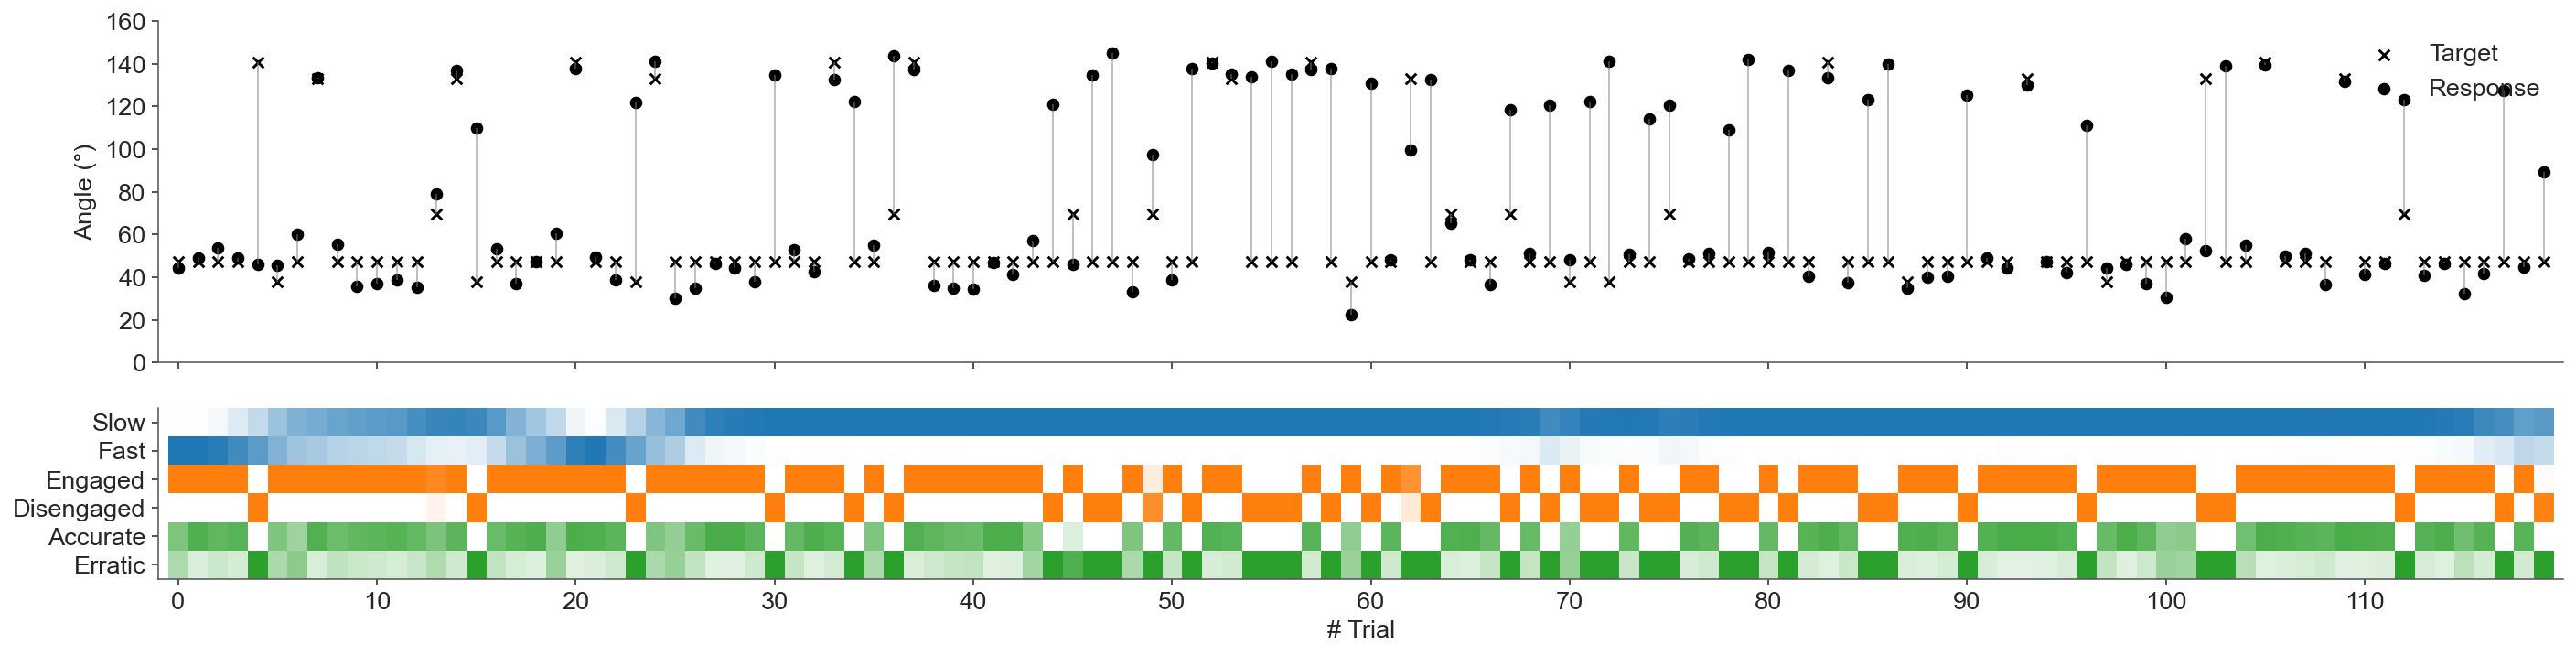

In [323]:
td = r_table[ (r_table.subj == 2) & (r_table.sess == 0) & (r_table.run == 3) ][["t_calib", "resp"]]
target = td.t_calib.values
resp = td.resp.values

fig, axs = plt.subplots(2, 1, figsize=(20, 5), sharex=True, 
                        gridspec_kw={'height_ratios': [1, 0.5], 'hspace': 0.1})

ax = plot_block(target, resp, y_min=0, y_max=160, y_step=20, ax=axs[0])
ax = make_heatmap(axs[1], example[:, 1, 3, :])

plt.show()

## Prob Correlations

In [324]:
import numpy as np
from scipy.stats import pearsonr, ttest_1samp
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt

In [326]:
# slow_post, fast_post, engaged_post, disengaged_post, accurate_post, erratic_post

slow↔engaged: mean r=0.076 ± 0.007, p=0.000
slow↔accurate: mean r=0.038 ± 0.008, p=0.000
engaged↔accurate: mean r=0.596 ± 0.021, p=0.000


/tmp/ipykernel_646076/1930963299.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_sa[s, sess], _ = pearsonr(x, z)
/tmp/ipykernel_646076/1930963299.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_ea[s, sess], _ = pearsonr(y, z)
/tmp/ipykernel_646076/1930963299.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels)


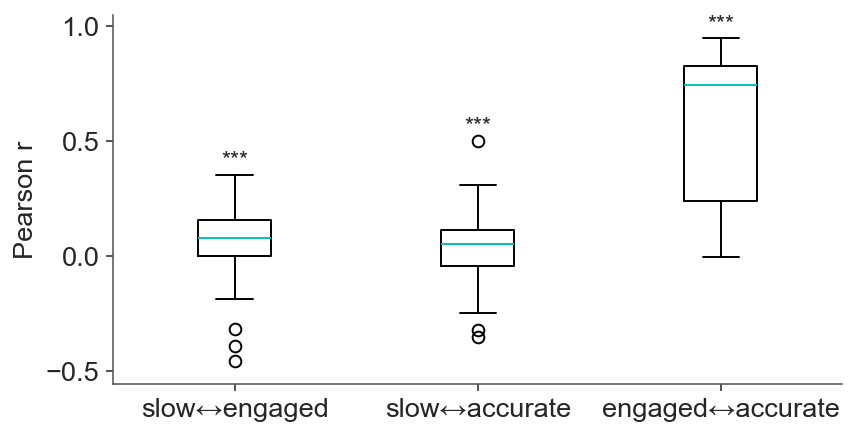

In [344]:
# ----------------------------
# ASSUMES EXISTING VARIABLES:
# slow_post, fast_post,
# engaged_post, disengaged_post,
# accurate_post, erratic_post
# all of shape (S, N, T)
# ----------------------------

S, N, T = slow_post.shape

# 1) Compute per‐session Pearson correlations
corr_se = np.zeros((S, N))  # slow↔engaged
corr_sa = np.zeros((S, N))  # slow↔accurate
corr_ea = np.zeros((S, N))  # engaged↔accurate

for s in range(S):
    for sess in range(N):
        x = slow_post[s, sess]
        y = engaged_post[s, sess]
        z = accurate_post[s, sess]
        corr_se[s, sess], _ = pearsonr(x, y)
        corr_sa[s, sess], _ = pearsonr(x, z)
        corr_ea[s, sess], _ = pearsonr(y, z)

# 2) Mask NaNs and summarize with t‐tests
def summarize_and_test(r_mat):
    flat = r_mat.flatten()
    valid = ~np.isnan(flat)
    m = flat[valid].mean()
    sem = flat[valid].std(ddof=1) / np.sqrt(valid.sum())
    t, p = ttest_1samp(flat[valid], 0)
    return flat[valid], m, sem, p

r_se_valid, m_se, sem_se, p_se = summarize_and_test(corr_se)
r_sa_valid, m_sa, sem_sa, p_sa = summarize_and_test(corr_sa)
r_ea_valid, m_ea, sem_ea, p_ea = summarize_and_test(corr_ea)

print(f"slow↔engaged: mean r={m_se:.3f} ± {sem_se:.3f}, p={p_se:.3f}")
print(f"slow↔accurate: mean r={m_sa:.3f} ± {sem_sa:.3f}, p={p_sa:.3f}")
print(f"engaged↔accurate: mean r={m_ea:.3f} ± {sem_ea:.3f}, p={p_ea:.3f}")

# 3) Star‐annotation helper
def stars(p):
    if   p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    else:           return 'n.s.'

# 4) Plot with stars
fig, ax = plt.subplots( figsize=(6, 3))
data = [r_se_valid, r_sa_valid, r_ea_valid]
labels = ['slow↔engaged','slow↔accurate','engaged↔accurate']
bp = ax.boxplot(data, labels=labels)
# # rotate x‐labels
# plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Pearson r')
# plt.title('Session‐wise Correlations')

# Annotate each box with its significance star
p_vals = [p_se, p_sa, p_ea]
for i, p in enumerate(p_vals):
    x = i + 1
    y = max(data[i]) + 0.02
    ax.text(x, y, stars(p), ha='center', va='bottom', fontsize=12)

plt.ylim(bottom=min([min(d) for d in data]) - 0.1, top=max([max(d) for d in data]) + 0.1)
plt.show()


In [351]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# assume slow_post, fast_post, engaged_post, disengaged_post, accurate_post, erratic_post 
# are already in memory with shape (S, N, T)
S, N, T = slow_post.shape

# sliding‐window width
w = 20
n_steps = T - w + 1
trials_center = np.arange(w//2, T - w//2 + 1)

# define the three pairs
pairs = [
    (slow_post,        engaged_post,        'slow↔engaged'),
    (slow_post,        accurate_post,       'slow↔accurate'),
    (engaged_post,     accurate_post,       'engaged↔accurate'),
]

# container for mean & SEM
results = {}

for A, B, name in pairs:
    # compute sliding-window r for each session
    r_win = np.zeros((S, N, n_steps))
    for s in range(S):
        for sess in range(N):
            x = A[s, sess]
            y = B[s, sess]
            for i in range(n_steps):
                xi = x[i : i + w]
                yi = y[i : i + w]
                if xi.std() == 0 or yi.std() == 0:
                    r_win[s, sess, i] = np.nan
                else:
                    r_win[s, sess, i], _ = pearsonr(xi, yi)
    flat = r_win.reshape(-1, n_steps)
    mean_r = np.nanmean(flat, axis=0)
    sem_r  = np.nanstd(flat, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(flat), axis=0))
    results[name] = (mean_r, sem_r)



/tmp/ipykernel_646076/1479886689.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


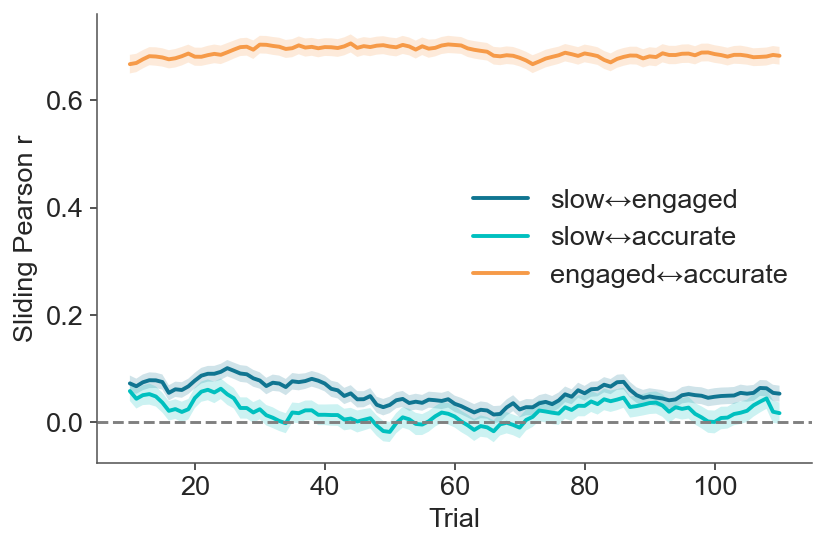

In [355]:
# plot all three
plt.figure(figsize=(6,4))
for name, (mean_r, sem_r) in results.items():
    plt.fill_between(trials_center,
                     mean_r - sem_r,
                     mean_r + sem_r,
                     alpha=0.2,
                    #  label=f'{name} ±1 SEM'
                     )
    plt.plot(trials_center,
             mean_r,
             lw=2,
             label=name)

plt.axhline(0, color='gray', ls='--')
plt.xlabel('Trial')
plt.ylabel(f'Sliding Pearson r')
# plt.title('Time‐resolved sliding‐window correlations')
plt.legend(loc='center right', ncol=1)
plt.tight_layout()
plt.show()
